# Walkthrough - Trees & Ensembles in Practice

In this walkthrough we will:
1. Use the **bootstrap** to compute a confidence interval for a statistic with no closed-form formula.
2. See how unstable a single **decision tree** is.
3. Fix it with **bagging / random forests**, and use the **OOB error** for free validation.
4. Train **gradient boosting** (sklearn, XGBoost, CatBoost) and compare.

Companion lessons: Lessons 01-05 of this chapter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score

RNG = np.random.default_rng(0)  # one seeded generator for reproducibility

## Part 1 - The Bootstrap

We estimate the **median** of a skewed distribution, and want a confidence interval for it.
There is no simple analytic formula for the standard error of a median - but the bootstrap
doesn't care.

median = 1.050, bootstrap SE = 0.099, 95% CI = [0.864, 1.246]


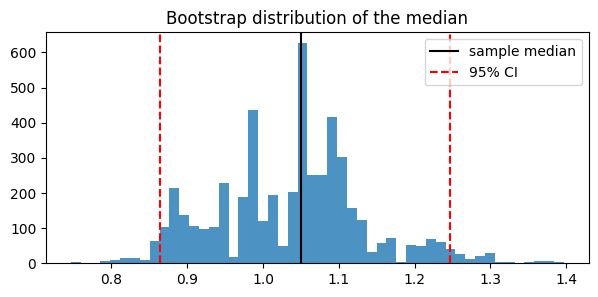

In [2]:
n = 200
data = RNG.lognormal(mean=0.0, sigma=1.0, size=n)  # skewed data
theta_hat = np.median(data)

B = 5000
boot_medians = np.empty(B)
for b in range(B):
    resample = RNG.choice(data, size=n, replace=True)  # sample from F_hat
    boot_medians[b] = np.median(resample)

se_boot = boot_medians.std(ddof=1)
ci = np.percentile(boot_medians, [2.5, 97.5])  # percentile interval
print(f"median = {theta_hat:.3f}, bootstrap SE = {se_boot:.3f}, 95% CI = [{ci[0]:.3f}, {ci[1]:.3f}]")

plt.figure(figsize=(7, 3))
plt.hist(boot_medians, bins=50, alpha=0.8)
plt.axvline(theta_hat, color="k", label="sample median")
plt.axvline(ci[0], color="r", ls="--", label="95% CI")
plt.axvline(ci[1], color="r", ls="--")
plt.title("Bootstrap distribution of the median")
plt.legend()
plt.show()

The histogram *is* an estimate of the sampling distribution of the median.
Also verify the 63.2% fact from the lesson: how many distinct points does a resample contain?

In [3]:
frac_in = np.mean([len(np.unique(RNG.choice(n, size=n, replace=True))) / n for _ in range(1000)])
print(f"average fraction of distinct points in a bootstrap resample: {frac_in:.3f} (theory: 1 - 1/e = {1 - np.exp(-1):.3f})")

average fraction of distinct points in a bootstrap resample: 0.633 (theory: 1 - 1/e = 0.632)


## Part 2 - A Single Tree Is Unstable

We train the same depth-limited tree on two random halves of the same dataset and
compare the learned structures: the root split can change entirely.

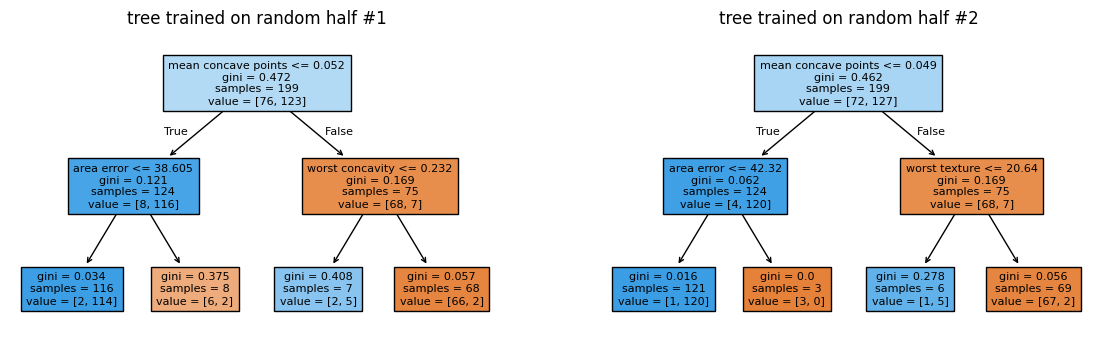

In [4]:
X, y = load_breast_cancer(return_X_y=True)
feature_names = load_breast_cancer().feature_names
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, seed in zip(axes, [1, 2]):
    idx = RNG.choice(len(X_train), size=len(X_train) // 2, replace=False)
    tree = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X_train[idx], y_train[idx])
    plot_tree(tree, feature_names=feature_names, filled=True, ax=ax, fontsize=8)
    ax.set_title(f"tree trained on random half #{seed}")
plt.show()

Same data distribution, different trees - this is the *variance* that ensembles attack.

## Part 3 - Random Forest and the OOB Error

More trees never hurt (the variance term decays like $\frac{1-\rho}{B}\sigma^2$).
Watch the OOB error stabilize as $B$ grows - no validation split needed.

/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(
/private/tmp/claude-501/-Users-cfirhadar-Desktop-GitRepos-AAI/8a1435a8-b7fd-4fdf-b47f-a438a003816c/scratchpad/venv/lib/python3.10/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


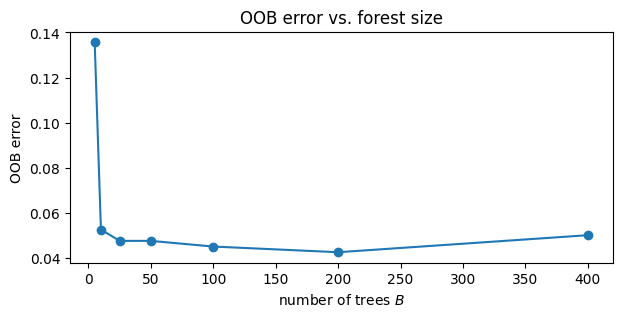

OOB accuracy:  0.9497
test accuracy: 0.9591  <- OOB is an honest estimate


In [5]:
n_trees_grid = [5, 10, 25, 50, 100, 200, 400]
oob_errors = []
for B_trees in n_trees_grid:
    rf = RandomForestClassifier(
        n_estimators=B_trees, oob_score=True, n_jobs=-1, random_state=0
    ).fit(X_train, y_train)
    oob_errors.append(1 - rf.oob_score_)

plt.figure(figsize=(7, 3))
plt.plot(n_trees_grid, oob_errors, "o-")
plt.xlabel("number of trees $B$")
plt.ylabel("OOB error")
plt.title("OOB error vs. forest size")
plt.show()

rf = RandomForestClassifier(n_estimators=400, oob_score=True, n_jobs=-1, random_state=0).fit(X_train, y_train)
print(f"OOB accuracy:  {rf.oob_score_:.4f}")
print(f"test accuracy: {rf.score(X_test, y_test):.4f}  <- OOB is an honest estimate")

### Feature importance: MDI vs permutation

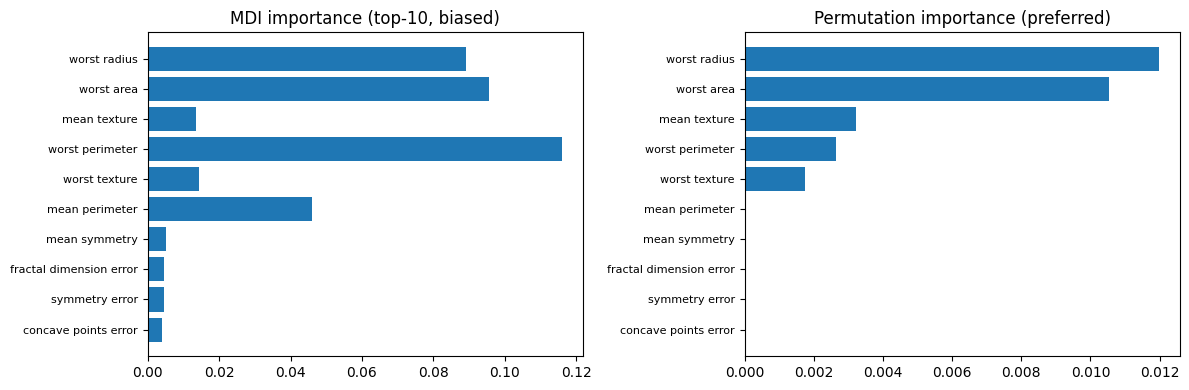

In [6]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(rf, X_test, y_test, n_repeats=20, random_state=0, n_jobs=-1)
order = np.argsort(perm.importances_mean)[-10:]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(range(10), rf.feature_importances_[order])
axes[0].set_yticks(range(10), feature_names[order], fontsize=8)
axes[0].set_title("MDI importance (top-10, biased)")
axes[1].barh(range(10), perm.importances_mean[order])
axes[1].set_yticks(range(10), feature_names[order], fontsize=8)
axes[1].set_title("Permutation importance (preferred)")
plt.tight_layout()
plt.show()

## Part 4 - Boosting: sklearn, XGBoost, CatBoost

Shallow trees, trained sequentially. Note the different bias: boosting uses weak
(depth-3) learners, the forest used deep ones.

In [7]:
import xgboost as xgb
from catboost import CatBoostClassifier

models = {
    "single tree (depth 3)": DecisionTreeClassifier(max_depth=3, random_state=0),
    "random forest": RandomForestClassifier(n_estimators=400, n_jobs=-1, random_state=0),
    "sklearn GBM": GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=0),
    "XGBoost": xgb.XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=0, verbosity=0),
    "CatBoost": CatBoostClassifier(iterations=300, learning_rate=0.05, depth=3, verbose=False, random_seed=0),
}
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name:24s} test accuracy = {accuracy_score(y_test, model.predict(X_test)):.4f}")

single tree (depth 3)    test accuracy = 0.9474


random forest            test accuracy = 0.9591


sklearn GBM              test accuracy = 0.9883
XGBoost                  test accuracy = 0.9649


CatBoost                 test accuracy = 0.9766


### Boosting overfits in the number of trees; bagging doesn't

We track the test error of gradient boosting *per stage* with a deliberately large
learning rate to make the overfitting visible, and compare to the forest's flat curve.

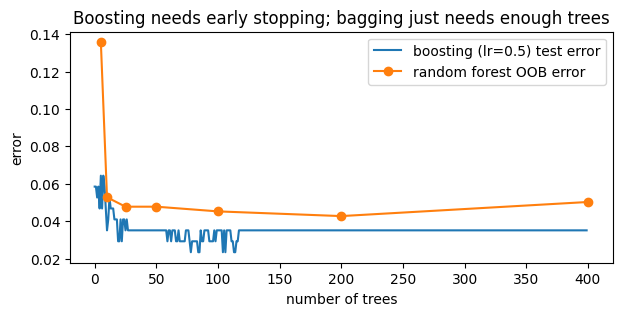

In [8]:
gbm = GradientBoostingClassifier(n_estimators=400, learning_rate=0.5, max_depth=3, random_state=0).fit(X_train, y_train)
boost_test_err = [1 - accuracy_score(y_test, y_pred) for y_pred in gbm.staged_predict(X_test)]

plt.figure(figsize=(7, 3))
plt.plot(boost_test_err, label="boosting (lr=0.5) test error")
plt.plot(n_trees_grid, oob_errors, "o-", label="random forest OOB error")
plt.xlabel("number of trees")
plt.ylabel("error")
plt.legend()
plt.title("Boosting needs early stopping; bagging just needs enough trees")
plt.show()

### TODO exercises

1. Refit XGBoost with `early_stopping_rounds=20` and an `eval_set` - how many trees does it actually keep?
2. Lower `learning_rate` to 0.01 in the plot above (and raise `n_estimators`). What happens to the overfitting?
3. In the random forest, sweep `max_features` over `[1, 3, 5, "sqrt", None]` and plot OOB error - find the correlation/strength tradeoff from Lesson 03.
4. CatBoost's specialty is *categorical* features. Bin two continuous features of this dataset into quartile categories, pass them via `cat_features=[...]`, and check whether accuracy survives.